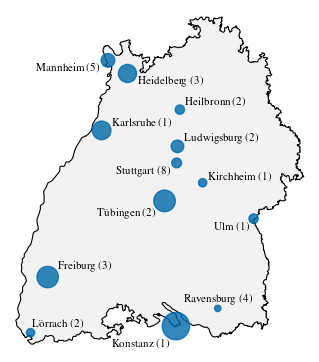

In [125]:
from tueplots import bundles
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


plt.rcParams.update(bundles.icml2024(column="half", nrows=2, ncols=1))

tue_red = (141/255, 45/255, 57/255)
tue_blue = (1/255, 105/255, 170/255)

states = gpd.read_file(
    "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/2_hoch.geo.json"
)

bw = states[states["name"] == "Baden-Württemberg"]

cities = [
    ("Freiburg", 47.997791, 7.842609, 236.60, 3),
    ("Heidelberg", 49.39875, 8.672434, 170.51, 3),
    ("Heilbronn", 49.150002, 9.2166, 44.81, 2),
    ("Karlsruhe", 49.006889, 8.403653, 179.76, 1),
    ("Kirchheim", 48.64683, 9.45378, 36.19, 1),
    ("Konstanz", 47.66033, 9.17582, 389.55, 1), 
    ("Lörrach", 47.61497, 7.66457, 35.64, 2),
    ("Ludwigsburg", 48.89731, 9.19161, 81.74, 2),
    ("Mannheim", 49.488888, 8.469167, 96.55, 5),
    ("Ravensburg", 47.78198, 9.61062, 21.04, 4),
    ("Stuttgart", 48.783333, 9.183333, 49.59, 8),
    ("Tübingen", 48.521637, 9.057645, 241.57, 2),
    ("Ulm", 48.400002, 9.983333, 45.19, 1),
]

cities = {
    "name": [city[0] for city in cities],
    "lat":  [city[1] for city in cities],
    "lon":  [city[2] for city in cities],
    "value": [city[3] for city in cities],
    "stations": [city[4] for city in cities],
}

geometry = [Point(xy) for xy in zip(cities["lon"], cities["lat"])]

cities_gdf = gpd.GeoDataFrame(
    cities,
    geometry=geometry,
    crs="EPSG:4326"
)

fig, ax = plt.subplots()


# Bundesland
bw.plot(
    ax=ax,
    facecolor="0.95",
    edgecolor="black",
    linewidth=0.8
)

# Marker
cities_gdf.plot(
    ax=ax,
    color=tue_blue,
    markersize=cities_gdf["value"],
    alpha=0.8
)

# Labels
for x, y, label, stations in zip(
    cities_gdf.geometry.x,
    cities_gdf.geometry.y,
    cities_gdf["name"],
    cities_gdf["stations"]
):  
    ha = "left"
    va = "bottom"
    if label == "Mannheim":
        ha = "right"
        va = "top"
        x -= 0.09
        y -= 0.02
    elif label == "Heidelberg":
        va = "top"
        x += 0.11
        y -= 0.02
    elif label == "Heilbronn":
        x += 0.05
        y += 0.02
    elif label == "Karlsruhe":
        x += 0.11
        y += 0.02
    elif label == "Ludwigsburg":
        x += 0.07
        y += 0.02
    elif label == "Stuttgart":
        ha = "right"
        va = "top"
        x -= 0.07
        y -= 0.02
    elif label == "Kirchheim":
        x += 0.06
        y += 0.01
    elif label == "Tübingen":
        ha = "right"
        va = "top"
        x -= 0.1
        y -= 0.05
    elif label == "Ulm":
        ha = "right"
        va = "top"
        x -= 0.04
        y -= 0.02
    elif label == "Freiburg":
        x += 0.11
        y += 0.04
    elif label == "Ravensburg":
        ha = "center"
        y += 0.03
    elif label == "Konstanz": 
        ha = "right"
        va = "top"
        x -= 0.07
        y -= 0.09
    elif label == "Lörrach":
        x += 0.01
        y += 0.03
    
    ax.text(x, y, label+f" ({stations})", ha=ha, va=va)

#ax.set_title("XXX", y=.97)
ax.axis("off")

plt.show()

fig.savefig("bw_cities_map.pdf", bbox_inches='tight')
